# Imports and Parameter

In [ ]:
import numpy as np
import simulation

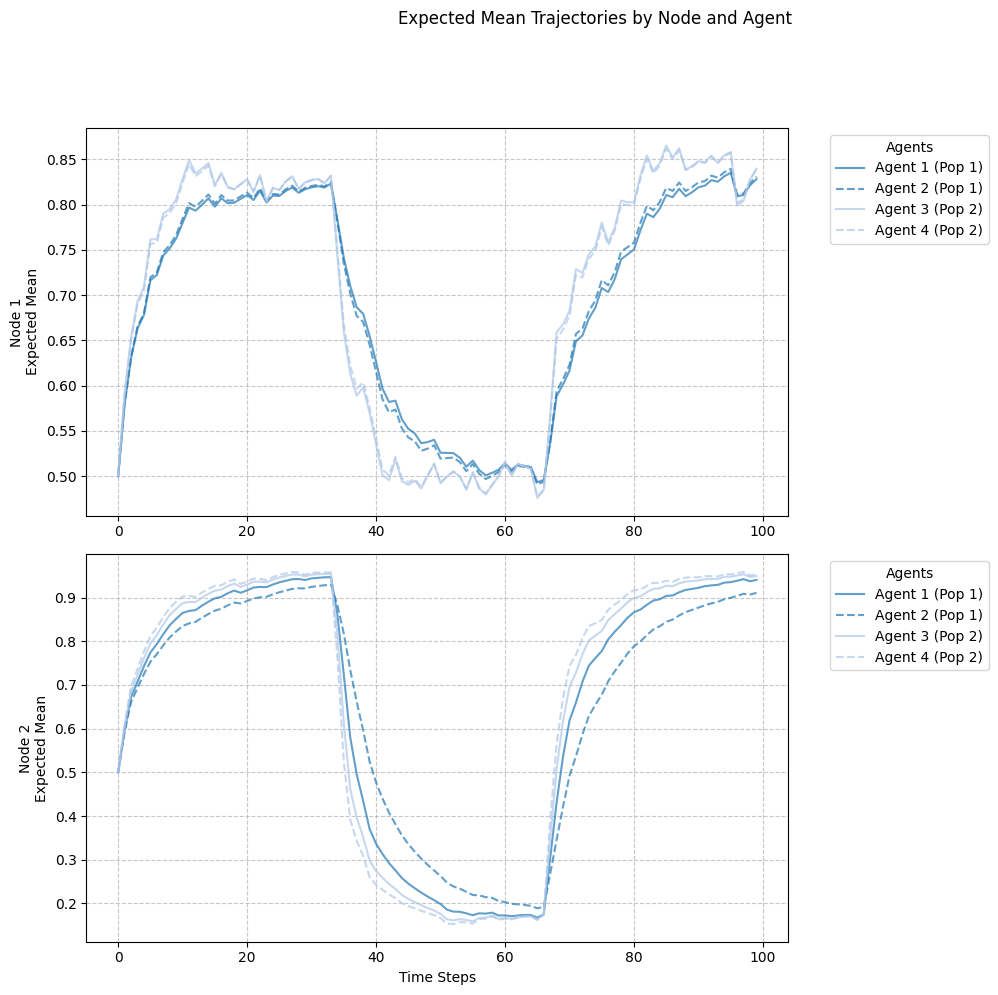

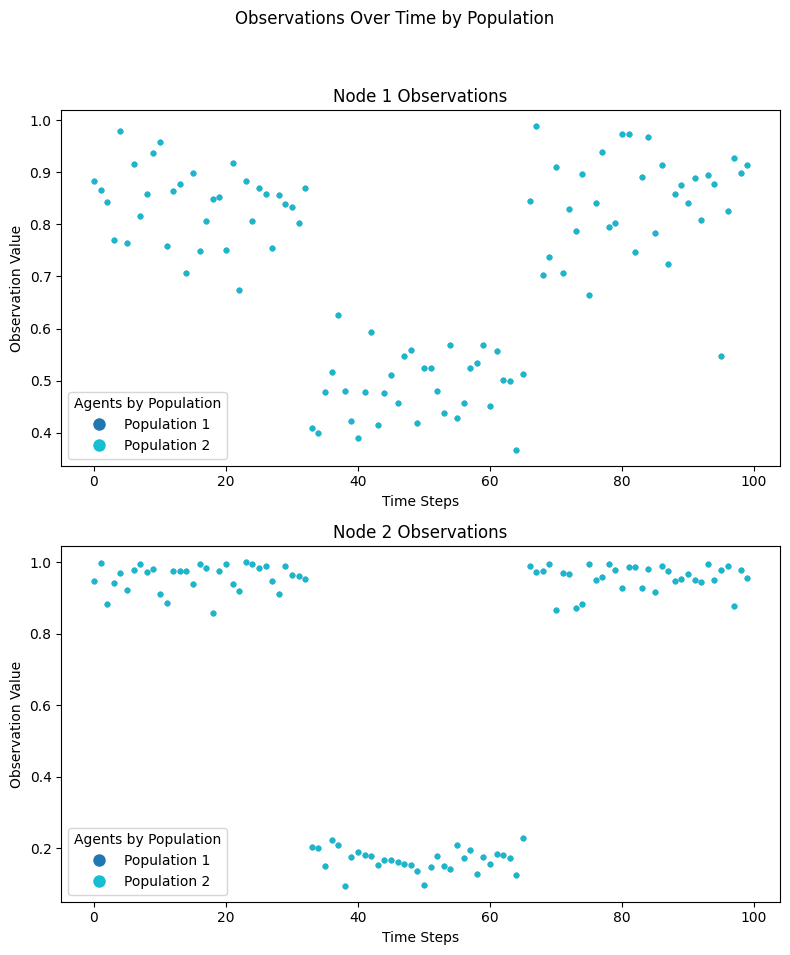

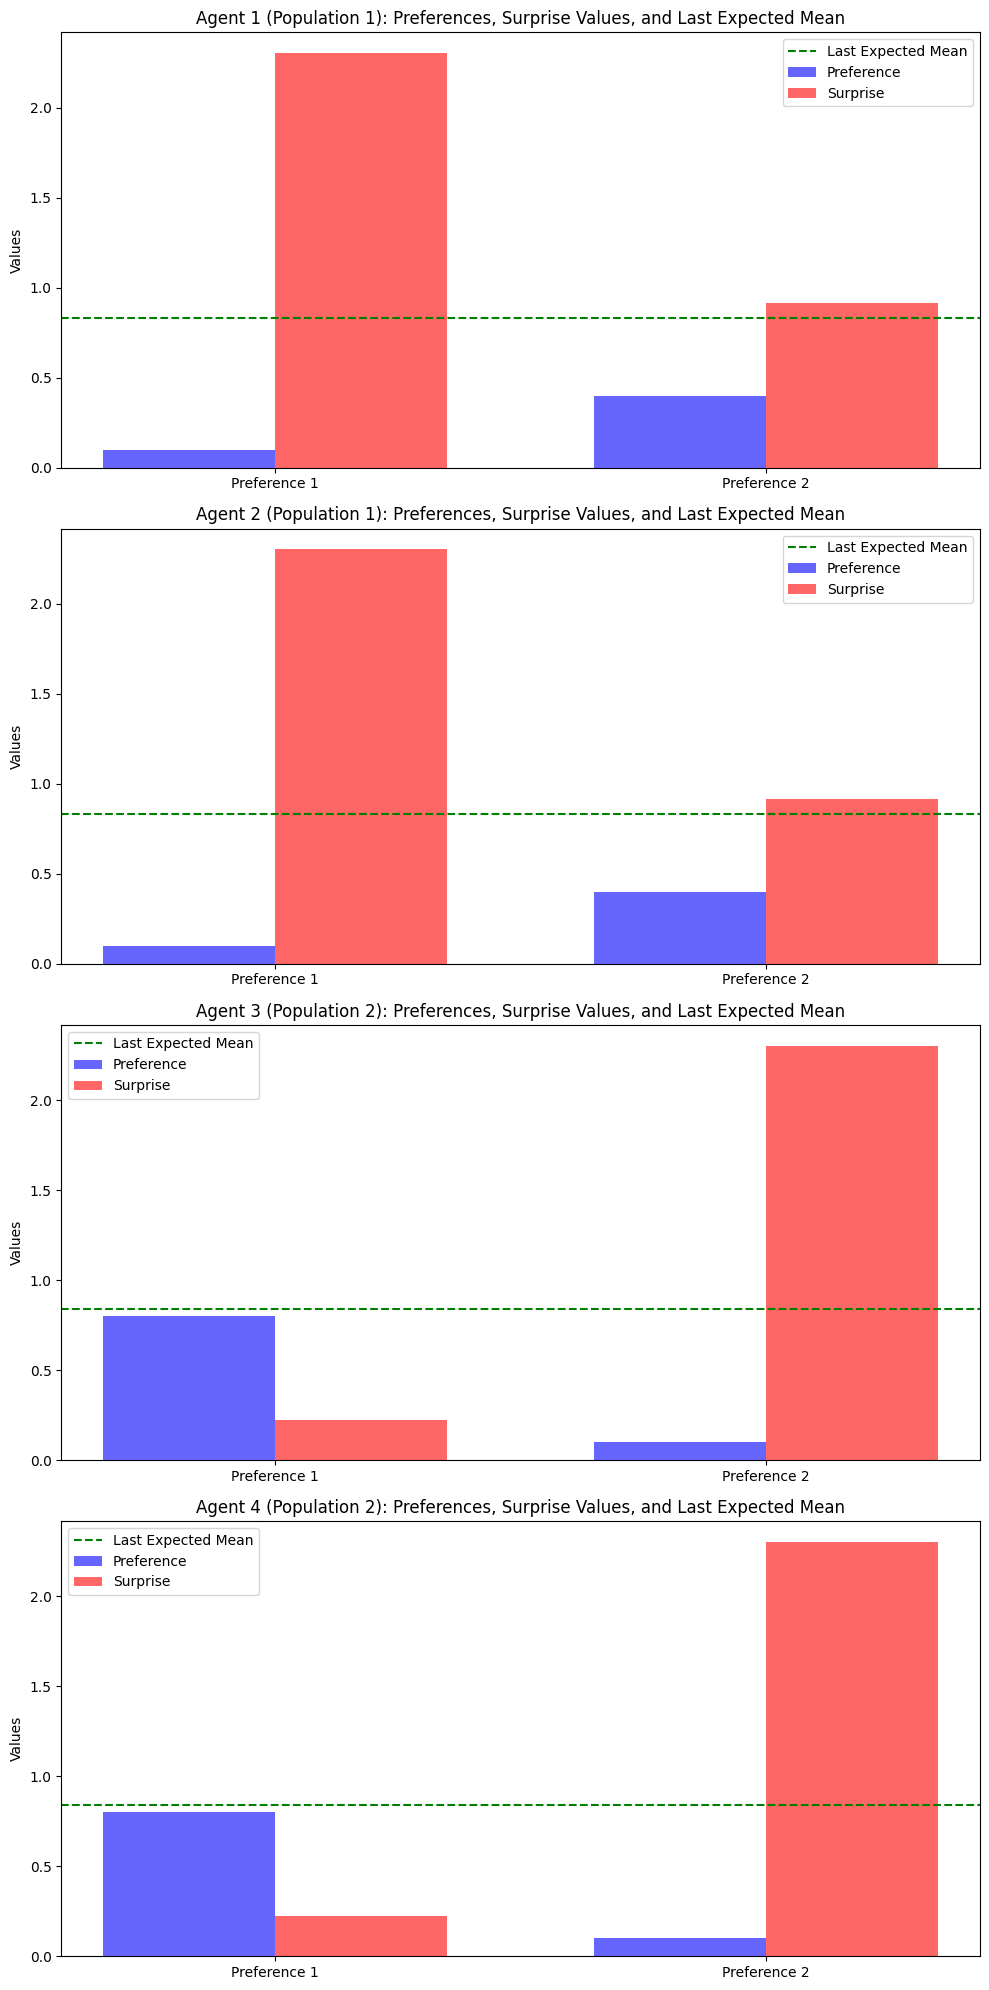

In [3]:
simulation = MultiAgentSimulation(n_steps=100, n_nodes=2 ,n_agents_per_population=2)

# Run simulation with default scenario
simulation.run_simulation(scenario=2)

# Plot trajectories, observations, and agent data
simulation.plot_trajectories()
simulation.plot_observations()
simulation.plot_agent_data()

In [4]:
voting_process(simulation)


NameError: name 'voting_process' is not defined

In [ ]:
    simulation = MultiAgentSimulation(n_steps=100, n_nodes=2, n_agents_per_population=2)

    voters, candidates = simulation.run_simulation(scenario=1)

    print("Résultats du vote :")
    for i, voter in enumerate(voters):
        chosen_candidate = voter.vote(candidates)
        if chosen_candidate:
            candidate_index = candidates.index(chosen_candidate) + 1
            print(f"Électeur {i+1} a voté pour le candidat {candidate_index}")
        else:
            print(f"Électeur {i+1} n'a pas voté (aucun candidat disponible)")

    vote_counts = {candidate: 0 for candidate in candidates}
    for voter in voters:
        if voter.voting_history:
            chosen_candidate = voter.voting_history[-1]['chosen_candidate']
            if chosen_candidate in vote_counts:
                vote_counts[chosen_candidate] += 1

    print("\nRésumé des votes :")
    for candidate, count in vote_counts.items():
        candidate_index = candidates.index(candidate) + 1
        print(f"Candidat {candidate_index} : {count} votes")
    simulation.plot_observations()
    simulation.plot_trajectories()
    simulation.plot_agent_data()



In [ ]:
    # Créer une simulation
simulation = MultiAgentSimulation(n_steps=500, n_nodes=2, n_agents_per_population=1)

# Définir les préférences pour les électeurs et les candidats
voter_preferences = np.array([0.1, 0.4, 0.3])
candidate_preferences = np.array([0.8, 0.1, 0.6])

# Définir les paramètres beta pour les électeurs et les candidats
beta_params_voter = (5, 1)
beta_params_candidate = (2, 2)

candidate = simulation.create_agent("candidate", tonic_volatility=-1, preferences=candidate_preferences, beta_params=beta_params_candidate)
simulation.run_simulation(scenario=1)

# Visualiser les résultats
simulation.plot_trajectories()
simulation.plot_observations()

    # Afficher les données des agents
simulation.plot_agent_data()

# Tracer les distributions de préférences avec transformation sigmoïde
MultiAgentSimulation.plot_preference_normals_all_agents(simulation, sigmoid=False, plot_beliefs=True)

    # Calculer la divergence KL pour les préférences
kl_divergences = MultiAgentSimulation.compute_kl_divergence_preferences(simulation, node_idx=1)
print("KL Divergences:", kl_divergences)

# Scenario 2

In [ ]:
# 2. Scénario avec choc soudain suivi d'un retour à la normale
print("Running sudden shock scenario with recovery...")
simulation = MultiAgentSimulation(n_steps=n_steps, n_nodes=2, n_agents_per_population=n_agents_per_population)
simulation.run_simulation(scenario=2, shock_pattern='sudden', shock_time=250, recovery_time=600)
simulation.plot_observations()
simulation.plot_trajectories()
simulation.plot_agent_data()
simulation.plot_preference_normals_all_agents(simulation, sigmoid=False, plot_beliefs=True)
# Example usage:
kl_divergences = MultiAgentSimulation.compute_kl_divergence_preferences(simulation, node_idx=1)
print(kl_divergences)

# Scenario 3

In [ ]:
# 3. Scénario avec tendance suivie d'un retour à la normale
print("Running trend scenario with recovery...")
simulation.run_simulation(scenario=2, shock_pattern='trend', recovery_time=100, trend_shape='sigmoid')
simulation.plot_observations()
simulation.plot_trajectories()
simulation.plot_agent_data()
simulation.plot_preference_normals_all_agents(simulation, sigmoid=False, plot_beliefs=True)
# Example usage:
kl_divergences = MultiAgentSimulation.compute_kl_divergence_preferences(simulation, node_idx=1)
print(kl_divergences)